# Building an NLP Pipeline and Sentiment Classifier from Scratch

In this project I build a full natural language processing pipeline from scratch, starting with text preprocessing and ending with a trained sentiment classifier. I implement several text-preprocessing techniques commonly used for NLP tasks, and then implement a standard text-classification algorithm to recognize the sentiment of movie reviews.

I assume familiarity with the `python` programming language and its libraries like `numpy` and `pandas`. I also make use of other libraries like `nltk` and `pytorch` throughout the project, with short explanations of their usage included along the way.

I load the SST-2 dataset from a local `data/SST-2/` folder relative to this notebook. The dataset (`train.tsv`, `dev.tsv`, `test.tsv`) can be downloaded from [here](https://dl.fbaipublicfiles.com/glue/data/SST-2.zip); unzip it so that `train.tsv` and `dev.tsv` sit inside `data/SST-2/` next to this notebook.

In [ ]:
data_dir = "data/SST-2"

In [3]:
# Install required libraries
!pip install numpy
!pip install pandas
!pip install nltk
!pip install torch
!pip install tqdm
!pip install matplotlib
!pip install seaborn

In [4]:
# I start by importing the libraries I will be using in this project.
import string
import tqdm
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download("punkt")
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Stanford Sentiment Treebank Dataset

For this project I work with the [Stanford Sentiment Treebank dataset](https://nlp.stanford.edu/sentiment/treebank.html), which comprises a list of movie reviews each tagged with the sentiment of the review. I use the binary label version of the dataset commonly referred to as **SST-2**, meaning each review has one of two possible labels, Positive or Negative.

The SST-2 dataset can be downloaded from [here](https://dl.fbaipublicfiles.com/glue/data/SST-2.zip). The dataset folder contains three `.tsv` files, `train.tsv`, `dev.tsv` and `test.tsv`, corresponding to the three splits of the data. Both `train.tsv` and `dev.tsv` have lines containing the reviews with the corresponding label (1 for positive sentiment and 0 for negative). Note that `test.tsv` only has the reviews, with labels missing, since this split comes from a competition where test predictions are submitted separately. For this project I focus on `train.tsv` and `dev.tsv` only, using the former for training the text classifiers and the latter for evaluating them.

I start by loading the datasets into memory.

In [5]:
# We can use pandas to load the datasets
train_df = pd.read_csv(f"{data_dir}/train.tsv", sep = "\t")
test_df = pd.read_csv(f"{data_dir}/dev.tsv", sep = "\t")

print(f"Number of Training Examples: {len(train_df)}")
print(f"Number of Test Examples: {len(test_df)}")

Number of Training Examples: 67349
Number of Test Examples: 872


In [6]:
# View a sample of the dataset
train_df.head()

,sentence,label
0,hide new secretions from the parental units,0
1,"contains no wit , only labored gags",0
2,that loves its characters and communicates som...,1
3,remains utterly satisfied to remain the same t...,0
4,on the worst revenge-of-the-nerds clichés the ...,0


As can be seen from the sample of the training dataset using `train_df.head()`, the dataframe contains columns `sentence` and `label` containing the review and sentiment label respectively.

As part of some preliminary data analysis below I visualize the distribution of the labels in the dataset.

<BarContainer object of 2 artists>

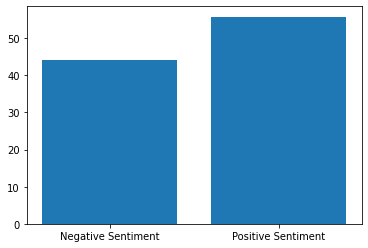

In [7]:
label_counts = 100 * train_df["label"].value_counts(normalize=True).sort_index()
plt.bar(x = ["Negative Sentiment", "Positive Sentiment"], height = label_counts)

As can be seen from the plot, roughly 45% of the training data points have a negative sentiment and about 55% have a positive sentiment.

## Preprocessing Pipeline for NLP

I start by implementing several text-preprocessing functions below, then run sanity checks after each one to confirm the function behaves as expected.

### Word Tokenization

Before preprocessing the text data and eventually training classification models, it is crucial to break the text into a set of constituents called tokens, which can be sentences, words, sub-words, or characters. For this project I focus on Word Tokenization, i.e. breaking a piece of text into a sequence of words.

There are different ways of splitting a piece of text into a list of words. The simplest approach is to split whenever a white-space character (i.e. `" "`) is encountered in the text, i.e. given a string `"this is an example of tokenization"`, iterating through it and splitting on each white space gives: `["this", "is", "an", "example", "of", "tokenization"]`. I implement the `whitespace_word_tokenize` function below.

In [8]:
def whitespace_word_tokenize(text):
  """
  Splits a python string containing some text to a sequence of words
  by splitting on whitespace.
  
  Parameters:
    - text (str): A Python string containing the text to be tokenized

  Returns:
    - words (list): A list contaning the words present in the text (in the same order)
  
  """
  words = None
  for word in range(len(text)):
    words = text.split(" ")
  # raise NotImplementedError()

  return words

In [9]:
def evaluate_list_test_cases(test_case_input,
                        test_case_func_output,
                        test_case_exp_output):
  
  print(f"Input: {test_case_input}")
  print(f"Function Output: {test_case_func_output}")
  print(f"Expected Output: {test_case_exp_output}")

  if test_case_func_output == test_case_exp_output:
    print("Test Case Passed :)")
    print("**********************************\n")
    return True
  else:
    print("Test Case Failed :(")
    print("**********************************\n")
    return False

  


print("Running Sample Test Cases")
print("Sample Test Case 1:")
test_case = "We all live in a Yellow Submarine"
test_case_answer = ['We', 'all', 'live', 'in', 'a', 'Yellow', 'Submarine']
test_case_student_answer = whitespace_word_tokenize(test_case)
assert evaluate_list_test_cases(test_case, test_case_student_answer, test_case_answer)

print("Sample Test Case 2:")
test_case = "We all live, in a Yellow Submarine."
test_case_answer = ['We', 'all', 'live,', 'in', 'a', 'Yellow', 'Submarine.']
test_case_student_answer = whitespace_word_tokenize(test_case)
assert evaluate_list_test_cases(test_case, test_case_student_answer, test_case_answer)


Running Sample Test Cases
Sample Test Case 1:
Input: We all live in a Yellow Submarine
Function Output: ['We', 'all', 'live', 'in', 'a', 'Yellow', 'Submarine']
Expected Output: ['We', 'all', 'live', 'in', 'a', 'Yellow', 'Submarine']
Test Case Passed :)
**********************************

Sample Test Case 2:
Input: We all live, in a Yellow Submarine.
Function Output: ['We', 'all', 'live,', 'in', 'a', 'Yellow', 'Submarine.']
Expected Output: ['We', 'all', 'live,', 'in', 'a', 'Yellow', 'Submarine.']
Test Case Passed :)
**********************************



As the outputs above show, the whitespace tokenizer does reasonably well at splitting a sentence into words. However, it is not perfect: as seen in the output of test case 2, this method fails to split words when punctuation is encountered, which gets retained as part of the words like `"live,"` and `"Submarine."`.

One possible solution is to split on punctuation as well as whitespace. This partially solves the problem, but there are other cases that still won't be handled properly, like wanting `"don't"` to be split into `["do", "n't"]` instead of `["don", "'", "t"]`.

Thankfully, the nltk package provides the `word_tokenize` function that handles most of these cases out of the box. I implement the `nltk_word_tokenize` function below, which uses the `word_tokenize` function from the nltk library to tokenize the text. The nltk documentation [here](https://www.nltk.org/api/nltk.tokenize.html#module-nltk.tokenize.treebank) describes the usage of `word_tokenize` in more detail.

In [10]:
from nltk.tokenize import word_tokenize

def nltk_word_tokenize(text):
  """
  Splits a python string containing some text to a sequence of words
  by using `word_tokenize` function from nltk.
  Refer to https://www.nltk.org/api/nltk.tokenize.html#module-nltk.tokenize.treebank
  
  Parameters:
    - text (str): A Python string containing the text to be tokenized

  Returns:
    - words (list): A list contaning the words present in the text (in the same order)
  """

  words = None
  words = word_tokenize(text)
  # raise NotImplementedError()

  return words

In [11]:
print("Running Sample Test Cases")
print("Sample Test Case 1:")
test_case = "We all live in a Yellow Submarine"
test_case_answer = ['We', 'all', 'live', 'in', 'a', 'Yellow', 'Submarine']
test_case_student_answer = nltk_word_tokenize(test_case)
assert evaluate_list_test_cases(test_case, test_case_student_answer, test_case_answer)

print("Sample Test Case 2:")
test_case = "We all live, in a Yellow Submarine."
test_case_answer = ['We', 'all', 'live', ',', 'in', 'a', 'Yellow', 'Submarine', '.']
test_case_student_answer = nltk_word_tokenize(test_case)
assert evaluate_list_test_cases(test_case, test_case_student_answer, test_case_answer)

print("Sample Test Case 3:")
test_case = "pi isn't a rational number and its approximate value is 3.14"
test_case_answer = ['pi', 'is', "n't", 'a', 'rational', 'number', 'and', 'its', 'approximate', 'value', 'is', '3.14']
test_case_student_answer = nltk_word_tokenize(test_case)
assert evaluate_list_test_cases(test_case, test_case_student_answer, test_case_answer)


Running Sample Test Cases
Sample Test Case 1:
Input: We all live in a Yellow Submarine
Function Output: ['We', 'all', 'live', 'in', 'a', 'Yellow', 'Submarine']
Expected Output: ['We', 'all', 'live', 'in', 'a', 'Yellow', 'Submarine']
Test Case Passed :)
**********************************

Sample Test Case 2:
Input: We all live, in a Yellow Submarine.
Function Output: ['We', 'all', 'live', ',', 'in', 'a', 'Yellow', 'Submarine', '.']
Expected Output: ['We', 'all', 'live', ',', 'in', 'a', 'Yellow', 'Submarine', '.']
Test Case Passed :)
**********************************

Sample Test Case 3:
Input: pi isn't a rational number and its approximate value is 3.14
Function Output: ['pi', 'is', "n't", 'a', 'rational', 'number', 'and', 'its', 'approximate', 'value', 'is', '3.14']
Expected Output: ['pi', 'is', "n't", 'a', 'rational', 'number', 'and', 'its', 'approximate', 'value', 'is', '3.14']
Test Case Passed :)
**********************************



Running the test cases above confirms that nltk does a much better job of splitting text into constituent words, separating punctuation from the words as well as handling subtleties like splitting `"isn't"` into `"is"` and `"n't"`, and retaining the full decimal `"3.14"`, which would have been split into `"3"` and `"14"` under a naive punctuation split.

### Convert the Text to Lower Case

I start with the most basic of all text preprocessing techniques: converting all the words in the text to lower case. As I show later, NLP models often treat different words as different entities and by default do not assume any relation between them. For example, the word `Bat` would be treated differently from the word `bat` if used separately to define features. It is useful to remove such artifacts from the dataset so that the same word has a common representation regardless of case.

I complete the function definition below.

In [12]:
def to_lower_case(text):
  """ Converts a piece of text to only contain words in lower case
  
  Parameters:
    - text (str): A Python string containing the text to be lower-cased

  Returns:
    - text_lower_case (str): A string containing the input text in lower case

  """

  text_lower_case = None
  text_lower_case  = text.lower()

  # raise NotImplementedError()

  return text_lower_case

In [13]:
"""Don't change code in this cell"""
#SAMPLE TEST CASE

def evaluate_string_test_cases(test_case_input,
                        test_case_func_output,
                        test_case_exp_output):
  
  print(f"Input: {test_case_input}")
  print(f"Function Output: {test_case_func_output}")
  print(f"Expected Output: {test_case_exp_output}")

  if test_case_func_output == test_case_exp_output:
    print("Test Case Passed :)")
    print("**********************************\n")
    return True
  else:
    print("Test Case Failed :(")
    print("**********************************\n")
    return False


print("Running Sample Test Cases")
print("Sample Test Case 1:")
test_case = "We all live in a Yellow Submarine"
test_case_answer = "we all live in a yellow submarine"
test_case_student_answer = to_lower_case(test_case)
assert evaluate_string_test_cases(test_case, test_case_student_answer, test_case_answer)

print("Sample Test Case 2:")
test_case = "SuRRender To The Void, iT is SHINNING"
test_case_answer = "surrender to the void, it is shinning"
test_case_student_answer = to_lower_case(test_case)
assert evaluate_string_test_cases(test_case, test_case_student_answer, test_case_answer)


Running Sample Test Cases
Sample Test Case 1:
Input: We all live in a Yellow Submarine
Function Output: we all live in a yellow submarine
Expected Output: we all live in a yellow submarine
Test Case Passed :)
**********************************

Sample Test Case 2:
Input: SuRRender To The Void, iT is SHINNING
Function Output: surrender to the void, it is shinning
Expected Output: surrender to the void, it is shinning
Test Case Passed :)
**********************************



### Remove Punctuation

Another common way to reduce the number of word variations in the text, like `hello` vs `hello,`, is to remove punctuation. While for some NLP tasks like POS tagging punctuation can be helpful, for classification tasks it can be assumed to have negligible effect on the actual label.

I complete the function `remove_punctuations` below. Examples of the function's expected behavior are:

| Input                                                                                                  | Expected Output                                                                                  |
|--------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------|
| Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal! | Mr and Mrs Dursley of number four Privet Drive were proud to say that they were perfectly normal |
| "Little tyke," chortled Mr. Dursley as he left the house.                                              | Little tyke chortled Mr Dursley as he left the house                                             |


In [14]:
import string

def remove_punctuations(text):
  """ 
  Removes punctuations from a piece of text.
  
  Parameters:
    - text (str) : A Python string containing text from which punctuation is to be removed
  
  Returns:
    - text_no_punct (str): Resulting string after removing punctuation.

  Hint: You can use `string.punctuation` to get a string containing all punctuation symbols.
  >>> print(string.punctuation)
  '!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

  """

  text_no_punct = ("")
  exclist = string.punctuation
  for word in str(text):
    if word not in exclist:
      text_no_punct = text_no_punct + word
  # text_no_punct = None
  # text_no_punct = text.translate(str.maketrans(text,string.punctuation))
  

  # raise NotImplementedError()

  return text_no_punct

In [15]:
print("Running Sample Test Cases")
print("Sample Test Case 1:")
test_case = "Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal!"
test_case_answer = "Mr and Mrs Dursley of number four Privet Drive were proud to say that they were perfectly normal"
test_case_student_answer = remove_punctuations(test_case)
assert evaluate_string_test_cases(test_case, test_case_student_answer, test_case_answer)

print("Sample Test Case 2:")
test_case = "\"Little tyke,\" chortled Mr. Dursley as he left the house."
test_case_answer = "Little tyke chortled Mr Dursley as he left the house"
test_case_student_answer = remove_punctuations(test_case)
assert evaluate_string_test_cases(test_case, test_case_student_answer, test_case_answer)


Running Sample Test Cases
Sample Test Case 1:
Input: Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal!
Function Output: Mr and Mrs Dursley of number four Privet Drive were proud to say that they were perfectly normal
Expected Output: Mr and Mrs Dursley of number four Privet Drive were proud to say that they were perfectly normal
Test Case Passed :)
**********************************

Sample Test Case 2:
Input: "Little tyke," chortled Mr. Dursley as he left the house.
Function Output: Little tyke chortled Mr Dursley as he left the house
Expected Output: Little tyke chortled Mr Dursley as he left the house
Test Case Passed :)
**********************************



### Remove Stop Words

There are some commonly used words in a language, like in English 'the', 'a', 'I', 'he', that might not provide much valuable information for the task at hand and can therefore be removed from the text. For a task like POS tagging this shouldn't be done, but for sentiment classification the labels can be assumed to be largely independent of the presence of such words.

The choice of stop words to use can be subjective and in many cases depends on the problem at hand. For this project I use the stop words for the English language present in the `nltk` package. The code for obtaining these stop words is given in the following cell.

In [16]:
from nltk.corpus import stopwords
STOPWORDS = stopwords.words("english")
",".join(STOPWORDS)

"i,me,my,myself,we,our,ours,ourselves,you,you're,you've,you'll,you'd,your,yours,yourself,yourselves,he,him,his,himself,she,she's,her,hers,herself,it,it's,its,itself,they,them,their,theirs,themselves,what,which,who,whom,this,that,that'll,these,those,am,is,are,was,were,be,been,being,have,has,had,having,do,does,did,doing,a,an,the,and,but,if,or,because,as,until,while,of,at,by,for,with,about,against,between,into,through,during,before,after,above,below,to,from,up,down,in,out,on,off,over,under,again,further,then,once,here,there,when,where,why,how,all,any,both,each,few,more,most,other,some,such,no,nor,not,only,own,same,so,than,too,very,s,t,can,will,just,don,don't,should,should've,now,d,ll,m,o,re,ve,y,ain,aren,aren't,couldn,couldn't,didn,didn't,doesn,doesn't,hadn,hadn't,hasn,hasn't,haven,haven't,isn,isn't,ma,mightn,mightn't,mustn,mustn't,needn,needn't,shan,shan't,shouldn,shouldn't,wasn,wasn't,weren,weren't,won,won't,wouldn,wouldn't"

As the output above shows, the stop words contain commonly used words that may not provide much information for the downstream task. I implement the function `remove_stop_words` below using the list of stop words given by `STOPWORDS` in the cell above.

Note that the stop words list contains words in lower case, so I convert a word in the text to lower case using the `to_lower_case` function implemented above before checking if it is present in the stop words list.

In [17]:
def remove_stop_words(text):
  """ 
  Removes stop words given in `nltk.corpus.stopwords.words("english)` from a piece of text.
  
  Parameters:
    - text (str) : A Python string containing text from which stop words are to be removed
  
  Returns:
    - text_no_sw (str): Resulting string after removing stop words.

  Hint: You should use `nltk_word_tokenize` for splitting the text
        into words

  """
  STOPWORDS = stopwords.words("english")
  text_no_sw = None
  word_tokens = word_tokenize(text)
  tokens_no_sw = [word for word in word_tokens if not word in STOPWORDS]
  text_no_sw = (" ").join(tokens_no_sw)


  # raise NotImplementedError()

  return text_no_sw

In [18]:
print("Running Sample Test Cases")
print("Sample Test Case 1:")
test_case = "Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal!"
test_case_answer = "Mr. Mrs. Dursley , number four , Privet Drive , proud say perfectly normal !"
test_case_student_answer = remove_stop_words(test_case)
assert evaluate_string_test_cases(test_case, test_case_student_answer, test_case_answer)



Running Sample Test Cases
Sample Test Case 1:
Input: Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal!
Function Output: Mr. Mrs. Dursley , number four , Privet Drive , proud say perfectly normal !
Expected Output: Mr. Mrs. Dursley , number four , Privet Drive , proud say perfectly normal !
Test Case Passed :)
**********************************



### Stemming

It is often beneficial to group together different inflections of a word into a single term. For example, *organizes* and *organizing* are morphological inflections of the word *organize*, and replacing instances of *organizes* and *organizing* with *organize* in the text data helps reduce the number of unique words in the vocabulary. Stemming is one approach to reduce inflectional forms into a common base form.

One common way of performing stemming is the *Suffix Removal* family of algorithms, which involves removing certain suffixes from a word based on a predefined set of rules, like:
- If the word ends with 's' remove 's' (denoted as S-> ϵ.eg. plays -> play)
- If the word ends with 'es' remove 'es' (denoted as ES-> ϵ. eg. mangoes -> mango).
- If the word ends with 'ing' remove 'ing'. (denoted as ING -> ϵ. eg. enjoying  -> enjoying)
- If the word ends with 'ly' remove 'ly'. (denoted as LY -> ϵ. eg. badly -> bad)

Many more similar rules can be defined to build a more sophisticated stemmer. Here I implement a simple stemmer that uses only these 4 rules to stem words in a sentence. I complete the `stem_word` and `stem_text` functions below.

In [19]:
def stem_word(word):
  """
  Give a word performs suffix removal stemming on it using the following 4 rules:
    - S -> ϵ
    - ES -> ϵ
    - ING -> ϵ
    - LY -> ϵ
  If none of the four suffixes is to be found in the word, the it must be returned
  as it is.
  Parameters:
    - word (str) : A python string representing the word to stemmed

  Returns:
    - stemmed_word (str): `word` after stemming

  HINT: It is possible that two rules can be satisfied like for mangoes
  both the first two rules are satisfied i.e. it ends with 'es' as well as 's'
  In such cases consider the suffix with the larger length which is 'es'
  in this case.
  """

  stemmed_word = None
  # suffixes = ['s','es','ing','ly']
  # if word.endswith(suffixes):
  #   stemmed_word = word[:-len(suffixes)]

  if word.endswith('ing'):
    stemmed_word = word[:-len('ing')]
  elif word.endswith('es'):
    stemmed_word = word[:-len('es')]
  elif word.endswith('ly'):
    stemmed_word = word[:-len('ly')]
  elif word.endswith('s'):
    stemmed_word = word[:-len('s')]
  else:
    return word


  # raise NotImplementedError()
  return stemmed_word



def stem_text(text):
  """
  Stems all the words in a piece of text, by calling `stem_word` for each word.

  Parameters:
    - text (str): A Python string containing text whose words are to be stemmed.

  Returns:
    - stemmed_text (str) : Resulting string after stemming.

  HINT: You should use `nltk_word_tokenize` for splitting the text
        into words

  """

  stemmed_text = None
  word_tokens = word_tokenize(text)
  tokens_no_sw = [stem_word(word) for word in word_tokens]
  stemmed_text = (" ").join(tokens_no_sw)

  
  # raise NotImplementedError()
  return stemmed_text


In [20]:
# Sample test cases for `stem_word`

print("Running Sample Test Cases")
print("Sample Test Case 1:")
test_case = "mangoes"
test_case_answer = "mango"
test_case_student_answer = stem_word(test_case)
assert evaluate_string_test_cases(test_case, test_case_student_answer, test_case_answer)

print("Sample Test Case 2:")
test_case = "plays"
test_case_answer = "play"
test_case_student_answer = stem_word(test_case)
assert evaluate_string_test_cases(test_case, test_case_student_answer, test_case_answer)

print("Sample Test Case 3:")
test_case = "enjoying"
test_case_answer = "enjoy"
test_case_student_answer = stem_word(test_case)
assert evaluate_string_test_cases(test_case, test_case_student_answer, test_case_answer)

print("Sample Test Case 4:")
test_case = "badly"
test_case_answer = "bad"
test_case_student_answer = stem_word(test_case)
assert evaluate_string_test_cases(test_case, test_case_student_answer, test_case_answer)

print("Sample Test Case 5:")
test_case = "fly"
test_case_answer = "f"
test_case_student_answer = stem_word(test_case)
assert evaluate_string_test_cases(test_case, test_case_student_answer, test_case_answer)

print("Sample Test Case 6:")
test_case = "connection"
test_case_answer = "connection"
test_case_student_answer = stem_word(test_case)
assert evaluate_string_test_cases(test_case, test_case_student_answer, test_case_answer)


Running Sample Test Cases
Sample Test Case 1:
Input: mangoes
Function Output: mango
Expected Output: mango
Test Case Passed :)
**********************************

Sample Test Case 2:
Input: plays
Function Output: play
Expected Output: play
Test Case Passed :)
**********************************

Sample Test Case 3:
Input: enjoying
Function Output: enjoy
Expected Output: enjoy
Test Case Passed :)
**********************************

Sample Test Case 4:
Input: badly
Function Output: bad
Expected Output: bad
Test Case Passed :)
**********************************

Sample Test Case 5:
Input: fly
Function Output: f
Expected Output: f
Test Case Passed :)
**********************************

Sample Test Case 6:
Input: connection
Function Output: connection
Expected Output: connection
Test Case Passed :)
**********************************



In [21]:
# Sample test cases for `stem_text`

print("Sample Test Case 1:")
test_case = "he sits and eats mangoes"
test_case_answer = "he sit and eat mango"
test_case_student_answer = stem_text(test_case)
assert evaluate_string_test_cases(test_case, test_case_student_answer, test_case_answer)

print("Sample Test Case 2:")
test_case = "he was badly hurt after playing"
test_case_answer = "he wa bad hurt after play"
test_case_student_answer = stem_text(test_case)
assert evaluate_string_test_cases(test_case, test_case_student_answer, test_case_answer)

print("Sample Test Case 3:")
test_case = "fly my little birds"
test_case_answer = "f my little bird"
test_case_student_answer = stem_text(test_case)
assert evaluate_string_test_cases(test_case, test_case_student_answer, test_case_answer)

print("Sample Test Case 4:")
test_case = "i am facing a poor network connection"
test_case_answer = "i am fac a poor network connection"
test_case_student_answer = stem_text(test_case)
assert evaluate_string_test_cases(test_case, test_case_student_answer, test_case_answer)


Sample Test Case 1:
Input: he sits and eats mangoes
Function Output: he sit and eat mango
Expected Output: he sit and eat mango
Test Case Passed :)
**********************************

Sample Test Case 2:
Input: he was badly hurt after playing
Function Output: he wa bad hurt after play
Expected Output: he wa bad hurt after play
Test Case Passed :)
**********************************

Sample Test Case 3:
Input: fly my little birds
Function Output: f my little bird
Expected Output: f my little bird
Test Case Passed :)
**********************************

Sample Test Case 4:
Input: i am facing a poor network connection
Function Output: i am fac a poor network connection
Expected Output: i am fac a poor network connection
Test Case Passed :)
**********************************



As shown above, the toy stemmer I just implemented is not perfect. Limited to the 4 rules, it misses some obvious cases, like reducing *connection* to *connect*, and sometimes over-stems a word, like reducing *fly* to `f`, which loses the meaning of the original word. More sophisticated algorithms use a larger set of rules and heuristics to avoid such situations. One of the most commonly used stemming algorithms is the `Porter Stemmer`, which uses a 5-step procedure involving different suffix removal and modification rules to perform stemming. More detail on how the Porter Stemmer works is available [here](https://vijinimallawaarachchi.com/2017/05/09/porter-stemming-algorithm/).

While implementing a sophisticated stemmer like Porter from scratch would be fairly involved, many python packages like *NLTK* (https://www.nltk.org/) provide ready-made implementations of a variety of stemming algorithms. Below I demonstrate using the `stem_word` function with different stemmers provided by NLTK.

In [22]:
# Importing the stemmers from NLTK
from nltk.stem import PorterStemmer
from nltk.stem import LancasterStemmer
from nltk.stem import SnowballStemmer
def stem_word_with_nltk(word, stemmer_type = "porter"):

  """
  Stems a word using Porter Stemmer from NLTK
    - word (str) : A python string representing the word to be stemmed

  Returns:
    - stemmed_word (str): `word` after stemming
  """

  # Initialize an object of the stemer class
  if stemmer_type == "porter":
    stemmer = PorterStemmer()
  elif stemmer_type == "lancaster":
    stemmer = LancasterStemmer()
  elif stemmer_type == "snowball":
    #Snowball stemmer works for multiple languages hence one should be specified during initialization
    stemmer = SnowballStemmer("english")
  else:
    stemmer = PorterStemmer()

  # Call the `stem` method
  stemmed_word = stemmer.stem(word)

  return stemmed_word

def stem_text_with_nltk(text, stemer_type = "porter"):

  """
  Stems all the words in a piece of text using NLTK's stemers, by calling `stem_word_with_nltk` for each word.

  Parameters:
    - text (str): A Python string containing text whose words are to be stemmed.

  Returns:
    - stemmed_text (str) : Resulting string after stemming.


  """

  stemmed_text = None

  stemmed_text = " ".join([stem_word_with_nltk(word) for word in word_tokenize(text)])

  return stemmed_text

In [23]:
input = "connection"
porter_output = stem_word_with_nltk(input, "porter")
lancester_output = stem_word_with_nltk(input, "lancaster")
snowball_output = stem_word_with_nltk(input, "snowball")

print(f"Input: {input}")
print(f"Porter Stemmer Output: {porter_output}")
print(f"Lancaster Stemmer Output: {lancester_output}")
print(f"Snowball Stemmer Output: {snowball_output}")

print("*******************************************\n")

input = "fly"
porter_output = stem_word_with_nltk(input, "porter")
lancester_output = stem_word_with_nltk(input, "lancaster")
snowball_output = stem_word_with_nltk(input, "snowball")

print(f"Input: {input}")
print(f"Porter Stemmer Output: {porter_output}")
print(f"Lancaster Stemmer Output: {lancester_output}")
print(f"Snowball Stemmer Output: {snowball_output}")

print("*******************************************\n")


input = "happiness"
porter_output = stem_word_with_nltk(input, "porter")
lancester_output = stem_word_with_nltk(input, "lancaster")
snowball_output = stem_word_with_nltk(input, "snowball")

print(f"Input: {input}")
print(f"Porter Stemmer Output: {porter_output}")
print(f"Lancaster Stemmer Output: {lancester_output}")
print(f"Snowball Stemmer Output: {snowball_output}")

print("*******************************************\n")


input = "operational"
porter_output = stem_word_with_nltk(input, "porter")
lancester_output = stem_word_with_nltk(input, "lancaster")
snowball_output = stem_word_with_nltk(input, "snowball")

print(f"Input: {input}")
print(f"Porter Stemmer Output: {porter_output}")
print(f"Lancaster Stemmer Output: {lancester_output}")
print(f"Snowball Stemmer Output: {snowball_output}")

Input: connection
Porter Stemmer Output: connect
Lancaster Stemmer Output: connect
Snowball Stemmer Output: connect
*******************************************

Input: fly
Porter Stemmer Output: fli
Lancaster Stemmer Output: fly
Snowball Stemmer Output: fli
*******************************************

Input: happiness
Porter Stemmer Output: happi
Lancaster Stemmer Output: happy
Snowball Stemmer Output: happi
*******************************************

Input: operational
Porter Stemmer Output: oper
Lancaster Stemmer Output: op
Snowball Stemmer Output: oper


As shown above, these stemmers recognize various types of cases for stemming and do a better job than my toy implementation. However, even these stemmers make errors, like reducing *operational* to *op* with the Lancaster stemmer. This happens because stemming algorithms fundamentally rely on heuristics to reduce inflectional forms without any proper morphological analysis. **Lemmatization** is another common technique used to reduce different forms of a word to a common term called a *lemma*, making use of a predefined vocabulary and morphological analysis of the words. Lemmatizers often work better when supplied with *Part of Speech tags*, which is a topic I plan to explore later, so I revisit lemmatization then.

### Combining the Preprocessing Functions into a Single Pipeline

Now that I have implemented the main preprocessing functions useful for a text classification task, I combine them into a single function that applies these 4 preprocessing techniques over a piece of text. I then use this function to preprocess the movie reviews in the training and dev datasets.

I implement the `preprocess_pipeline` and `preprocess_sentiment_data` functions below, where the former combines the 4 preprocessing functions implemented above and the latter applies that pipeline to all the reviews in the dataset.

Note: the order in which different preprocessing functions are applied can lead to different results. For example, since all of the stop words are in lower case, the text must be converted to lower case before stop words are removed. I follow this order when applying the preprocessing functions:

  1. to_lower_case
  2. remove_punctuations
  3. remove_stop_words
  4. stem_text_with_nltk (called with `stemer_type = "porter"`)

In [24]:
def preprocess_pipeline(text):

  """
  Given a piece of text applies preprocessing techniques
  like converting to lower case, removing stop words and punctuations,
  and stemming.

  Apply the functions in the following order:
  1. to_lower_case
  2. remove_punctuations
  3. remove_stop_words
  4. stem_text_with_nltk (call this with `stemer_type = "porter"`)

  Inputs:
    - text (str) : A python string containing text to be pre-processed
  
  Returns:
    - text_preprocessed (str) : Resulting string after applying preprocessing
  """

  text_preprocessed = None
  text_preprocessed = to_lower_case(text)
  text_preprocessed = remove_punctuations(text_preprocessed)
  text_preprocessed = remove_stop_words(text_preprocessed)
  # word_tokens = word_tokenize(text)
  tokens_no_sw = stem_text_with_nltk(text_preprocessed,stemer_type = "porter")
  text_preprocessed = ("").join(tokens_no_sw)
  
  # raise NotImplementedError()

  return text_preprocessed

In [25]:
print("Running Sample Test Cases")
print("Sample Test Case 1:")
test_case = "Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal!"
test_case_answer = "mr mr dursley number four privet drive proud say perfectli normal"
test_case_student_answer = preprocess_pipeline(test_case)
assert evaluate_string_test_cases(test_case, test_case_student_answer, test_case_answer)

print("Sample Test Case 2:")
test_case = "\"Little tyke,\" chortled Mr. Dursley as He left the house."
test_case_answer = "littl tyke chortl mr dursley left hous"
test_case_student_answer = preprocess_pipeline(test_case)
assert evaluate_string_test_cases(test_case, test_case_student_answer, test_case_answer)


Running Sample Test Cases
Sample Test Case 1:
Input: Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal!
Function Output: mr mr dursley number four privet drive proud say perfectli normal
Expected Output: mr mr dursley number four privet drive proud say perfectli normal
Test Case Passed :)
**********************************

Sample Test Case 2:
Input: "Little tyke," chortled Mr. Dursley as He left the house.
Function Output: littl tyke chortl mr dursley left hous
Expected Output: littl tyke chortl mr dursley left hous
Test Case Passed :)
**********************************



In [26]:
def preprocess_sentiment_data(df):
  """
  Takes the pandas dataframe containing SST-2 data as input and applies
  the `preprocess_pipeline` function to the its sentence column.

  Inputs:
    - df (pd.DataFrame): A pandas dataframe containing the SST-2 data with format:
        | sentence  | label  |
        ----------------------
        | sentence_1| label_1|
        | sentence_2| label_2|
        | ..........| .......|
        | ..........| .......|
  
  Returns (pd.DataFrame):
   - df_preprocessed: Resulting dataframe after applying `preprocessing_pipeline`
    to the `sentence` column. Note that the column names of df_preprocessed
    should be same as df and its should have the same number of rows as `df`.


  Hint: Look up how to use `pd.DataFrame.apply` method in pandas

  """

  df_preprocessed = None
  df['sentence'] = df['sentence'].apply(preprocess_pipeline)
  df_preprocessed = df
  # raise NotImplementedError()
  return df_preprocessed


In [27]:
# Preprocess the train and test sets. This might take a few minutes
train_df_preprocessed = preprocess_sentiment_data(train_df)
test_df_preprocessed = preprocess_sentiment_data(test_df)
print(train_df_preprocessed.head())
print("***************************")
print(test_df_preprocessed.head())


                                            sentence  label
0                        hide new secret parent unit      0
1                              contain wit labor gag      0
2  love charact commun someth rather beauti human...      1
3           remain utterli satisfi remain throughout      0
4  worst revengeofthenerd cliché filmmak could dredg      0
***************************
                                            sentence  label
0                         charm often affect journey      1
1                         unflinchingli bleak desper      0
2  allow us hope nolan pois embark major career c...      1
3  act costum music cinematographi sound astound ...      1
4                                          slow slow      0


In [28]:
type(train_df_preprocessed)

pandas.core.frame.DataFrame

In [29]:
print("Running Sample Test Cases")
print("Sample Test Case 1: Checking if the object returned is a pandas Dataframe")
assert isinstance(train_df_preprocessed, pd.DataFrame)
print("Test Case Passed :)")
print("***********************************\n")

print("Sample Test Case 2: Checking if the returned dataframe has correct columns")
student_column_names = sorted(list(train_df_preprocessed.columns))
expected_column_names = ["label", "sentence"]

assert student_column_names == expected_column_names
print("Test Case Passed :)")
print("***********************************\n")

print("Sample Test Case 3: Checking if the number of rows of the returned dataframe is same as the original dataframes")
assert len(train_df) == len(train_df_preprocessed) and len(test_df) == len(test_df_preprocessed)
print("Test Case Passed :)")
print("***********************************\n")
print("Sample Test Case 4: Checking if the returned dataframe has sentences preprocessed")

student_output = train_df_preprocessed["sentence"].values[1]
expected_output = "contain wit labor gag"
assert evaluate_string_test_cases(train_df["sentence"].values[1], student_output, expected_output)


Running Sample Test Cases
Sample Test Case 1: Checking if the object returned is a pandas Dataframe
Test Case Passed :)
***********************************

Sample Test Case 2: Checking if the returned dataframe has correct columns
Test Case Passed :)
***********************************

Sample Test Case 3: Checking if the number of rows of the returned dataframe is same as the original dataframes
Test Case Passed :)
***********************************

Sample Test Case 4: Checking if the returned dataframe has sentences preprocessed
Input: contain wit labor gag
Function Output: contain wit labor gag
Expected Output: contain wit labor gag
Test Case Passed :)
**********************************



## Bag of Words Models for Text Classification

Now that preprocessing of the reviews in the datasets is done, I can begin building a classifier to classify them into positive or negative sentiment.

Typical ML models work on data described using mathematical objects like vectors and matrices, often referred to as features. These features can be of different types depending on the downstream application; for example, to build a classifier that decides whether to extend credit to a customer, features like age, income, and employment status might be used. To build a classifier for textual data, I need a way to describe each text example in terms of numeric features that can then be fed into the classification algorithm of choice.

The bag of words model is one of the simplest but surprisingly effective ways to represent text data for building machine learning models. In a bag of words representation, the occurrence (or frequency) of each word in a given text example is used as a feature for training the classifier. The order in which words occur in the text is not relevant; only which words are present matters. Consider the following example to see how bag of words is used to represent text.

As an example, consider two examples in the dataset:

x1: john likes to watch movies mary likes movies too

x2: mary also likes to watch football games

Based on these two documents I can get the list of all words that occur in the dataset:

| index | word     |
|-------|----------|
| 0     | also     |
| 1     | football |
| 2     | games    |
| 3     | john     |
| 4     | likes    |
| 5     | mary     |
| 6     | movies   |
| 7     | to       |
| 8     | too      |
| 9     | watch    |

I can then define features for x1 and x2 as follows:

|    | also | football | games | john | likes | mary | movies | to | too | watch |
|----|------|----------|-------|------|-------|------|--------|----|-----|-------|
| x1 | 0    | 0        | 0     | 1    | 2     | 1    | 2      | 1  | 2   | 1     |
| x2 | 1    | 1        | 1     | 0    | 1     | 1    | 0      | 0  | 0   | 0     |

These features can then be used to train an ML model. To summarize, the following two steps are followed to create bag of words representations of the text examples in a dataset:

- Step 1: Create a word vocabulary by iterating through all the documents in the **training** dataset, storing all the unique words present in each document. Also maintain mappings from each word to an index and vice versa, needed to define values for each feature dimension.

- Step 2: For each document in the training and test sets, get the frequency of each word in the vocabulary and use it to define the feature vector for that example.

Below I implement functions to create bag of words representations of the dataset examples.

### Create Vocabularies

As described above, the first step is to create a word vocabulary for the documents in the dataset. I implement the `create_vocab` function below, which takes a list of documents as input and creates a list of unique words that occur in them.

In [30]:
def create_vocab(documents):
  """
  Given a list of documents each represented as a string,
  create a word vocabulary containing all the words that occur
  in these documents.

  Inputs:
    - documents (list) : A list with each element as a string representing a
    document.

  Returns:
    - vocab (list) : A **sorted** list containing all unique words in the
    documents

  Example Input: ['john likes to watch movies mary likes movies too',
                  'mary also likes to watch football games']

  Expected Output: ['also',
                    'football',
                    'games',
                    'john',
                    'likes',
                    'mary',
                    'movies',
                    'to',
                    'too',
                    'watch']


  Hint: `nltk_word_tokenize` function may come in handy

  """

  vocab = []
 
  for sent in documents:
      for word in word_tokenize(sent):
          if word not in vocab:
              vocab.append(word)

  # raise NotImplementedError()

  return sorted(vocab) # Don't change this

In [31]:
print("Running Sample Test Cases")
print("Sample Test Case 1:")

test_case = ["john likes to watch movies mary likes movies too",
              "mary also likes to watch football games"]
test_case_answer = ['also', 'football', 'games', 'john', 'likes', 'mary', 'movies', 'to', 'too', 'watch']
test_case_student_answer = create_vocab(test_case)
assert evaluate_list_test_cases(test_case, test_case_student_answer, test_case_answer)

print("Sample Test Case 2:")

test_case = ["We all live in a yellow submarine.",
             "Yellow submarine, yellow submarine!!"
             ]
test_case_answer = ['!', ',', '.', 'We', 'Yellow', 'a', 'all', 'in', 'live', 'submarine', 'yellow']
test_case_student_answer = create_vocab(test_case)
assert evaluate_list_test_cases(test_case, test_case_student_answer, test_case_answer)



Running Sample Test Cases
Sample Test Case 1:
Input: ['john likes to watch movies mary likes movies too', 'mary also likes to watch football games']
Function Output: ['also', 'football', 'games', 'john', 'likes', 'mary', 'movies', 'to', 'too', 'watch']
Expected Output: ['also', 'football', 'games', 'john', 'likes', 'mary', 'movies', 'to', 'too', 'watch']
Test Case Passed :)
**********************************

Sample Test Case 2:
Input: ['We all live in a yellow submarine.', 'Yellow submarine, yellow submarine!!']
Function Output: ['!', ',', '.', 'We', 'Yellow', 'a', 'all', 'in', 'live', 'submarine', 'yellow']
Expected Output: ['!', ',', '.', 'We', 'Yellow', 'a', 'all', 'in', 'live', 'submarine', 'yellow']
Test Case Passed :)
**********************************



Note that the output of sample test case 2 contains punctuation as well as different upper-case and lower-case variants of a word detected as separate words. This illustrates the importance of performing preprocessing over the documents, since it reduces unnecessary entries like punctuation and stop words in the vocabulary and provides a common term for different variants of a word.

In [32]:
# Now that our `create_vocab` function is ready, let's create vocabulary for the SST dataset

train_documents = train_df_preprocessed["sentence"].values.tolist() # Note that we are selecting preprocessed documents
train_vocab = create_vocab(train_documents)

print(f"Training Vocabulary Created. Number of words: {len(train_vocab)}")

Training Vocabulary Created. Number of words: 10781


### Create Word-to-Index Mapping

Now that I have a list of words in the dataset, I can map each word to an index, which is useful for representing which word each feature dimension refers to. I implement the `get_word_idx_mappings` function below.

In [33]:
def get_word_idx_mapping(vocab):

  """
  Give a list of strings each representing a word in the vocabulary
  creates a dictionary that maps each word in the list to its
  corresponding index.

  Inputs:
    - vocab (list): A list of strings each representing a word in the vocabulary
  
  Outputs:
    - word2idx (dict): A Python dictionary mapping each word to its index in vocabulary

  Example Input: ['also',
                    'football',
                    'games',
                    'john',
                    'likes',
                    'mary',
                    'movies',
                    'to',
                    'too',
                    'watch']

  Expected Output: {'also': 0,
                  'football': 1,
                  'games': 2,
                  'john': 3,
                  'likes': 4,
                  'mary': 5,
                  'movies': 6,
                  'to': 7,
                  'too': 8,
                  'watch': 9}

  """

  # word2idx = {word: i for i, word in enumerate(vocab)}
  word2idx = dict(zip(vocab, range(len(vocab))))


  # raise NotImplementedError()

  return word2idx

In [34]:
print("Running Sample Test Cases")
print("Sample Test Case 1:")
test_case = ['also', 'football', 'games', 'john', 'likes', 'mary', 'movies', 'to', 'too', 'watch']
test_case_answer = {'also': 0, 'football': 1, 'games': 2, 'john': 3, 'likes': 4, 'mary': 5, 'movies': 6, 'to': 7, 'too': 8, 'watch': 9}
test_case_student_answer = get_word_idx_mapping(test_case)
assert evaluate_list_test_cases(test_case, test_case_student_answer, test_case_answer)



Running Sample Test Cases
Sample Test Case 1:
Input: ['also', 'football', 'games', 'john', 'likes', 'mary', 'movies', 'to', 'too', 'watch']
Function Output: {'also': 0, 'football': 1, 'games': 2, 'john': 3, 'likes': 4, 'mary': 5, 'movies': 6, 'to': 7, 'too': 8, 'watch': 9}
Expected Output: {'also': 0, 'football': 1, 'games': 2, 'john': 3, 'likes': 4, 'mary': 5, 'movies': 6, 'to': 7, 'too': 8, 'watch': 9}
Test Case Passed :)
**********************************



In [35]:
train_vocab2idx = get_word_idx_mapping(train_vocab)
train_vocab2idx 

{'1': 0,
 '10': 1,
 '100': 2,
 '10000': 3,
 '100minut': 4,
 '101': 5,
 '103minut': 6,
 '105': 7,
 '10cours': 8,
 '10th': 9,
 '10thgrade': 10,
 '10year': 11,
 '10yearold': 12,
 '11': 13,
 '110': 14,
 '112minut': 15,
 '12': 16,
 '120': 17,
 '127': 18,
 '129minut': 19,
 '12th': 20,
 '12yearold': 21,
 '13': 22,
 '13th': 23,
 '140': 24,
 '146': 25,
 '14yearold': 26,
 '15': 27,
 '15th': 28,
 '15year': 29,
 '163': 30,
 '168minut': 31,
 '170': 32,
 '1790': 33,
 '18': 34,
 '1899': 35,
 '18yearold': 36,
 '19': 37,
 '1920': 38,
 '1930': 39,
 '1933': 40,
 '1937': 41,
 '1938': 42,
 '1940': 43,
 '1950': 44,
 '1952': 45,
 '1957': 46,
 '1958': 47,
 '1959': 48,
 '1960': 49,
 '1962': 50,
 '1970': 51,
 '1972': 52,
 '1973': 53,
 '1975': 54,
 '1979': 55,
 '1980': 56,
 '1984': 57,
 '1986': 58,
 '1987': 59,
 '1989': 60,
 '1993': 61,
 '1994': 62,
 '1995': 63,
 '1997': 64,
 '1998': 65,
 '1999': 66,
 '19th': 67,
 '19thcenturi': 68,
 '2': 69,
 '20': 70,
 '2000': 71,
 '2001': 72,
 '2002': 73,
 '20car': 74,
 '20th

### Create Bag of Words Features for the Documents

Now that I have the list of words and a word-to-index mapping, I can create a bag of words feature vector for each document present in the training and test data. I implement the function `get_document_bow_feature`, which takes a document, a vocabulary, and a vocabulary-to-index mapping as input and returns the feature vector for the document.

In [36]:
def get_document_bow_feature(document, vocab, word2idx):
  """
  Given a string representing the document and the vocabulary, create a bag of
  words representation of the document i.e. a feature vector where each feature
  is defined as the frequency of each word in the vocabulary.

  Inputs:
   - document (str): A python string representing the document for which features are to be obtained
   - vocab (list): A list of words present in the vocabulary
   - word2idx (dict): A dictionary that maps each word to an index.

  Returns:
    - bow_feature (numpy.ndarray): A numpy array of size `len(vocab)` whose each element contains the count of each word in the vocabulary.

  Example Input:
    document = "john likes to watch movies mary likes movies too"
    vocab = ['also','football','games','john','likes','mary', 'movies','to','too','watch']
    word2idx = {'also': 0, 'football': 1, 'games': 2, 'john': 3, 'likes': 4, 'mary': 5, 'movies': 6, 'to': 7, 'too': 8, 'watch': 9}

  Expected Output: array([0, 0, 0, 1, 2, 1, 2, 1, 1, 1])

  """

  bow_feature = np.zeros(len(vocab))
  words = word_tokenize(document)
  for word in words:
    if word in vocab:
      bow_feature[word2idx[word]]=bow_feature[word2idx[word]]+1
    
   # raise NotImplementedError()

  return bow_feature

In [37]:
print("Running Sample Test Cases")
print("Sample Test Case 1:")
test_case = {"document": "john likes to watch movies mary likes movies too",
             "vocab": ['also', 'football', 'games', 'john', 'likes', 'mary', 'movies', 'to', 'too', 'watch'],
             "word2idx": {'also': 0, 'football': 1, 'games': 2, 'john': 3, 'likes': 4, 'mary': 5, 'movies': 6, 'to': 7, 'too': 8, 'watch': 9}
             }
test_case_answer = np.array([0, 0, 0, 1, 2, 1, 2, 1, 1, 1])
test_case_student_answer = get_document_bow_feature(**test_case)
assert evaluate_list_test_cases(test_case, test_case_student_answer.tolist(), test_case_answer.tolist())

print("Sample Test Case 2:")
test_case = {"document": "mary also likes to watch football games",
             "vocab": ['also', 'football', 'games', 'john', 'likes', 'mary', 'movies', 'to', 'too', 'watch'],
             "word2idx": {'also': 0, 'football': 1, 'games': 2, 'john': 3, 'likes': 4, 'mary': 5, 'movies': 6, 'to': 7, 'too': 8, 'watch': 9}
             }
test_case_answer = np.array([1, 1, 1, 0, 1, 1, 0, 1, 0, 1])
test_case_student_answer = get_document_bow_feature(**test_case)
assert evaluate_list_test_cases(test_case, test_case_student_answer.tolist(), test_case_answer.tolist())

print("Sample Test Case 3:")
test_case = {"document": "mary and jane also like to watch football games",
             "vocab": ['also', 'football', 'games', 'john', 'likes', 'mary', 'movies', 'to', 'too', 'watch'],
             "word2idx": {'also': 0, 'football': 1, 'games': 2, 'john': 3, 'likes': 4, 'mary': 5, 'movies': 6, 'to': 7, 'too': 8, 'watch': 9}
             }
test_case_answer = np.array([1, 1, 1, 0, 0, 1, 0, 1, 0, 1])
test_case_student_answer = get_document_bow_feature(**test_case)
assert evaluate_list_test_cases(test_case, test_case_student_answer.tolist(), test_case_answer.tolist())






Running Sample Test Cases
Sample Test Case 1:
Input: {'document': 'john likes to watch movies mary likes movies too', 'vocab': ['also', 'football', 'games', 'john', 'likes', 'mary', 'movies', 'to', 'too', 'watch'], 'word2idx': {'also': 0, 'football': 1, 'games': 2, 'john': 3, 'likes': 4, 'mary': 5, 'movies': 6, 'to': 7, 'too': 8, 'watch': 9}}
Function Output: [0.0, 0.0, 0.0, 1.0, 2.0, 1.0, 2.0, 1.0, 1.0, 1.0]
Expected Output: [0, 0, 0, 1, 2, 1, 2, 1, 1, 1]
Test Case Passed :)
**********************************

Sample Test Case 2:
Input: {'document': 'mary also likes to watch football games', 'vocab': ['also', 'football', 'games', 'john', 'likes', 'mary', 'movies', 'to', 'too', 'watch'], 'word2idx': {'also': 0, 'football': 1, 'games': 2, 'john': 3, 'likes': 4, 'mary': 5, 'movies': 6, 'to': 7, 'too': 8, 'watch': 9}}
Function Output: [1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0]
Expected Output: [1, 1, 1, 0, 1, 1, 0, 1, 0, 1]
Test Case Passed :)
**********************************

S

Now that the `get_document_bow_feature` function works properly, I get bag of words features for the examples in the datasets.

In [38]:
# Getting bow feature for one training document first
training_example = train_documents[0]
bow_feature = get_document_bow_feature(training_example,
                                       train_vocab,
                                       train_vocab2idx)
print(f"Length of bow feature: {len(bow_feature)}")
print(f"Number of non-zero entries in the bow feature: {len(bow_feature[bow_feature != 0])}")

Length of bow feature: 10781
Number of non-zero entries in the bow feature: 5


Since the vocabulary size is 10781, the bag of words vector for each document is of size 10781. With about 67k training examples, it isn't practical to store these high-dimensional vectors as-is for every document. Instead of storing the features for all documents in memory, I query the features while training the model in a batch-wise fashion, i.e. training on N examples at a time, such that N <<< 10781. This becomes clearer in the next section on datasets and dataloaders.

## Training a Linear Classifier Using Bag of Words Features

Now that I have defined numerical features to represent each document, I can start training a classifier on top of them. For this project I implement a linear classifier, namely **Logistic Regression**. I assume familiarity with logistic regression from a machine learning course; for a refresher, these [videos](https://www.youtube.com/watch?v=-la3q9d7AKQ&list=PLLssT5z_DsK-h9vYZkQkYNWcItqhlRJLN&index=32) are a good resource.

I use PyTorch to implement and train the logistic regression classifier for the sentiment prediction task. I start by implementing the dataset and dataloaders to iterate over the data, then move to defining the logistic regression module, the loss function, and an optimizer for training the model.

### Defining PyTorch Dataset and Dataloaders to Iterate over the SST-2 Dataset

When training neural networks, or in this case linear classifiers, it is often not practical to train over the entire dataset at once. Instead a batch-wise training strategy is used, iterating over different batches of the dataset, so it is useful to define iterators for doing this. Writing pipelines for processing data samples and iterators on top of them by hand can get messy quickly. PyTorch provides `torch.utils.data.Dataset` and `torch.utils.data.Dataloader` classes that make this much more convenient and modular.

`torch.utils.data.Dataset` provides a wrapper to store the dataset, which `torch.utils.data.Dataloader` then uses to define an iterable over the dataset. The tutorial [here](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) covers Dataset and Dataloader classes in more depth.

I start by defining a custom Dataset class for the dataset by extending the `torch.utils.data.Dataset` class. A custom Dataset class must implement three functions:
-  `__init__`: the constructor for the custom class, often used to store the (meta)data that the other functions use to create samples.
- `__len__`: returns the number of examples present in the dataset.
-  `__getitem__`: loads and returns a sample stored at the given index `idx`.

In [39]:
from torch.utils.data import Dataset, DataLoader


class SST2Dataset(Dataset):

  def __init__(self, documents, labels, vocab, word2idx):
    """
    Store dataset documents and labels here so that they can be used by
    __getitem__ to process and return the samples.

    Inputs:
      - documents (list): A list of strings containing reviews in our dataset.
      - labels (list): A list of sentiment labels (1 or 0) corresponding to each document.
      - vocab (list): A list of words present in the vocabulary
      - word2idx (dict): A dictionary that maps each word to an index.
    """

    self.documents = documents
    self.labels = labels
    self.vocab = vocab
    self.word2idx = word2idx

  def __len__(self):
    return len(self.documents)

  def __getitem__(self, idx):
    """
    Loads and returns the features and label corresponding to the `idx` index
    in the documents and labels lists.

    Inputs:
      - idx (index): Index of the dataset example to be loaded and returned

    Returns:
      - features (numpy.ndarray): The bag of word features corresponding the document indexed by `idx`
      - label (int): The sentiment label for the `idx`th document

    Hint: You can get the document and label by doing self.documents[idx],
    self.labels[idx]. Features of the document are to be extracted via
    `get_document_bow_feature` function
    """

    features, label = None, None
    features = get_document_bow_feature(self.documents[idx], self.vocab, self.word2idx)
    label = self.labels[idx]
    # raise NotImplementedError()

    return features, label

In [40]:
print("Running Sample Test Cases")

sample_documents = ["this movie is great",
                    "I HATED this film"]
sample_labels = [0, 1]
sample_vocab = create_vocab(sample_documents)
sample_word2idx = get_word_idx_mapping(sample_vocab)
sample_dataset = SST2Dataset(sample_documents, sample_labels,
                             sample_vocab, sample_word2idx)

test_case_idx = 0
features, label = sample_dataset.__getitem__(test_case_idx)

print(f"Sample Test Case 1: Testing Returned Labels for idx = {test_case_idx}")
print(f"Output Label: {label}")
print(f"Expected Label: {sample_labels[test_case_idx]}")
assert label == sample_labels[test_case_idx]
print("**********************************\n")

print(f"Sample Test Case 2: Testing returned Features for idx = {test_case_idx}")
expected_features = [0, 0, 0, 1, 1, 1, 1]

print(f"Output Features: {features.tolist()}")
print(f"Expected Features: {expected_features}")
assert expected_features == features.tolist()

test_case_idx = 1
features, label = sample_dataset.__getitem__(test_case_idx)
print("**********************************\n")

print(f"Sample Test Case 3: Testing Returned Labels for idx = {test_case_idx}")
print(f"Output Label: {label}")
print(f"Expected Label: {sample_labels[test_case_idx]}")
assert label == sample_labels[test_case_idx]
print("**********************************\n")

print(f"Sample Test Case 4: Testing returned Features for idx = {test_case_idx}")
expected_features = [1, 1, 1, 0, 0, 0, 1]
print(f"Output Features: {features.tolist()}")
print(f"Expected Features: {expected_features}")
assert expected_features == features.tolist()
print("**********************************\n")


Running Sample Test Cases
Sample Test Case 1: Testing Returned Labels for idx = 0
Output Label: 0
Expected Label: 0
**********************************

Sample Test Case 2: Testing returned Features for idx = 0
Output Features: [0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0]
Expected Features: [0, 0, 0, 1, 1, 1, 1]
**********************************

Sample Test Case 3: Testing Returned Labels for idx = 1
Output Label: 1
Expected Label: 1
**********************************

Sample Test Case 4: Testing returned Features for idx = 1
Output Features: [1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0]
Expected Features: [1, 1, 1, 0, 0, 0, 1]
**********************************



Now that the custom `SST2Dataset` class works as expected, I create objects for the training and test datasets.

In [41]:
# Get documents and labels from the dataset
train_documents = train_df_preprocessed["sentence"].values.tolist()
train_labels = train_df["label"].values.tolist()
test_documents = test_df_preprocessed["sentence"].values.tolist()
test_labels = test_df["label"].values.tolist()

# Create vocabulary from training data
train_vocab = create_vocab(train_documents)
train_word2idx = get_word_idx_mapping(train_vocab)

# Create datasets
train_dataset = SST2Dataset(train_documents,
                            train_labels,
                            train_vocab,
                            train_word2idx)
test_dataset = SST2Dataset(test_documents,
                           test_labels,
                           train_vocab,
                           train_word2idx
                           )

Note that I used the training data vocabulary for creating the test dataset as well. This is intentional: the model can only make use of features it was trained on, so the test set has to be represented using the same vocabulary and word-to-index mapping learned from training data, not its own.

Now that the training and test datasets are created, I can create dataloaders to iterate over them in batches. I use a batch size of 64 in these experiments. A lower batch size lowers memory requirements but makes training noisier. Since the features here are fairly high dimensional, I avoid too large a batch size, hence 64.

In [42]:
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size = batch_size)
test_dataloader = DataLoader(test_dataset, batch_size = batch_size)

Dataloaders behave like any other iterable in python (lists, dictionaries, etc.) and can be iterated over using a for loop like this:

In [43]:
for batch in train_dataloader:
  # Unpacking the batch
  features, labels = batch
  print(f"Features Shape: {features.shape}")
  print(f"Labels Shape: {labels.shape}")

  # We will break for now as this is just for demonstration
  break

Features Shape: torch.Size([64, 10781])
Labels Shape: torch.Size([64])


Notice how each batch unwraps into a features tensor and a labels tensor. Features is a 64x10781 tensor, where 64 is the batch size and 10781 is the number of features for each document. Torch tensors behave very similarly to numpy arrays, with the added benefit that they can be transferred to a GPU and support auto-differentiation. I revisit these points when implementing the training loop.

### Defining the Model Architecture for the Logistic Regression Classifier

PyTorch provides an elegantly designed `torch.nn` module containing building blocks for creating different neural network architectures. Some of the sub-modules included in `torch.nn` are:

- `torch.nn.Linear`: perhaps the simplest of the nn modules, used to apply a linear transformation to the data, i.e. y = xA^T + b, where x is the input and y is the output of the layer. A and b are the parameters of the layer, where A is often called the weight matrix and b is the bias vector.

- `torch.nn.Conv2d`: used to create convolutional layers.

- `torch.nn.Transformer`: used to create transformer layers.

and many more. For this project I only need `torch.nn.Linear` to define the network.

It also supports different activation functions like:
- `torch.nn.ReLU`
- `torch.nn.Sigmoid`
- `torch.nn.Tanh`
- `torch.nn.Softmax`

Below I demonstrate the usage of some of these modules.

In [44]:
import torch
import torch.nn as nn

# Create a linear layer that maps a 5 dimensional vector to a 3 dimensional vector
example_linear_layer = nn.Linear(5, 3) # Initialize a linear layer
example_input = torch.rand(5) # Create a random vector for demonstration
print(f"Input: {example_input}")
print(f"Input Shape: {example_input.shape}")
example_output = example_linear_layer(example_input) # Feed the example input to the linear layer
print(f"Linear layer output: {example_output}")
print(f"Linear layer output Shape: {example_output.shape}")

print("************************************************\n")

# We can also use linear layers with batched inputs
example_batch_input = torch.rand(4,5) # Create an example input containing 4 inputs of 5 dimension each
print(f"Batched Input:\n {example_batch_input}")
print(f"Batched Input Shape: {example_batch_input.shape}")
example_batch_output = example_linear_layer(example_batch_input)
print(f"Linear layer batched output:\n {example_batch_output}")
print(f"Linear layer batched output Shape: {example_batch_output.shape}")

print("************************************************\n")

# Using activation functions
sigmoid_activation = nn.Sigmoid() #Define sigmoid activation
relu_activation = nn.ReLU() #Define relu activation

sigmoid_output = sigmoid_activation(example_batch_output) # Apply the sigmoid function to the output of the linear layer
relu_output = relu_activation(example_batch_output) # Apply the relu function to the output of the linear layer
print(f"Before Applying the activation function:\n {example_batch_output}")
print(f"After Applying the sigmoid function:\n {sigmoid_output}")
print(f"After Applying the relu function:\n {relu_output}")

print("************************************************\n")


Input: tensor([0.8016, 0.4648, 0.9050, 0.5181, 0.5805])
Input Shape: torch.Size([5])
Linear layer output: tensor([-0.3797, -0.2174,  0.1598], grad_fn=<AddBackward0>)
Linear layer output Shape: torch.Size([3])
************************************************

Batched Input:
 tensor([[0.0168, 0.8726, 0.1138, 0.4349, 0.5880],
        [0.2770, 0.2831, 0.6293, 0.6480, 0.0624],
        [0.1690, 0.0779, 0.2953, 0.3335, 0.4530],
        [0.3815, 0.5841, 0.8840, 0.1512, 0.4605]])
Batched Input Shape: torch.Size([4, 5])
Linear layer batched output:
 tensor([[-0.2485, -0.0013,  0.4542],
        [-0.1031,  0.0404,  0.2571],
        [ 0.0155, -0.0101,  0.2449],
        [-0.1903, -0.0808,  0.1336]], grad_fn=<AddmmBackward0>)
Linear layer batched output Shape: torch.Size([4, 3])
************************************************

Before Applying the activation function:
 tensor([[-0.2485, -0.0013,  0.4542],
        [-0.1031,  0.0404,  0.2571],
        [ 0.0155, -0.0101,  0.2449],
        [-0.1903, -0.0

Notice how the outputs of the nn layers also contain a `grad_fn`. This is used during backpropagation to compute the gradients that the optimizer uses to learn the parameters of these layers.

A network is defined in PyTorch by extending the `torch.nn.Module` class and implementing the `__init__` and `forward` methods. The `__init__` method defines the components of the architecture, while `forward` takes an input tensor and passes it through the different layers of the network. The `torch.nn` documentation is available [here](https://pytorch.org/docs/stable/nn.html), and [this tutorial](https://pytorch.org/tutorials/beginner/nn_tutorial.html) covers it in more detail.

Below I implement the `LogisticRegressionModel` class.

In [45]:
import torch
import torch.nn as nn

class LogisticRegressionModel(nn.Module):

  def __init__(self, d_input):
    """
    Define the architecture of a Logistic Regression classifier.
    You will need to define two components, one will be the linear layer using
    nn.Linear, and a sigmoid activation function for the output.

    Inputs:
      - d_input (int): The dimensionality or number of features in each input. 
                        This will be required to define the linear layer

    Hint: Recall that in logistic regression we obtain a single probablility
    value for each input that denotes how likely is the input belonging
    to the positive class
    """
    #Need to call the constructor of the parent class
    output_dim = 1
    super(LogisticRegressionModel, self).__init__()

    self.linear_layer = None
    self.sigmoid_layer = None
    
    self.linear_layer = torch.nn.Linear(d_input, output_dim)
    # raise NotImplementedError()

  
  def forward(self, x):
    """
    Passes the input `x` through the layers in the network and returns the output

    Inputs:
      - x (torch.tensor): A torch tensor of shape [batch_size, d_input] representing the batch of inputs

    Returns:
      - output (torch.tensor): A torch tensor of shape [batch_size,] obtained after passing the input to the network

    """
    output = None

    self.sigmoid_layer = torch.sigmoid(self.linear_layer(x))
    output = self.sigmoid_layer
    # raise NotImplementedError()

    return output.squeeze(-1) # Question: Why do squeeze() here? 

In [46]:
print("Running Sample Test Cases")
torch.manual_seed(42)
d_input = 5
sample_lr_model = LogisticRegressionModel(d_input = d_input)
print(f"Sample Test Case 1: Testing linear layer input and output sizes, for d_input = {d_input}")
in_features = sample_lr_model.linear_layer.in_features
out_features = sample_lr_model.linear_layer.out_features

print(f"Number of Input Features: {in_features}")
print(f"Number of Output Features: {out_features}")
print(f"Expected Number of Input Features: {d_input}")
print(f"Expected Number of Output Features: {1}")
assert in_features == d_input and out_features == 1

print("**********************************\n")
d_input = 24
sample_lr_model = LogisticRegressionModel(d_input = d_input)
print(f"Sample Test Case 2: Testing linear layer input and output sizes, for d_input = {d_input}")
in_features = sample_lr_model.linear_layer.in_features
out_features = sample_lr_model.linear_layer.out_features

print(f"Number of Input Features: {in_features}")
print(f"Number of Output Features: {out_features}")
print(f"Expected Number of Input Features: {d_input}")
print(f"Expected Number of Output Features: {1}")
assert in_features == d_input and out_features == 1
print("**********************************\n")

print(f"Sample Test Case 3: Checking if the model gives correct output")
test_input = torch.rand(d_input)
model_output = sample_lr_model(test_input)
model_output_np = model_output.detach().numpy()
expected_output = 0.6298196315765381
print(f"Model Output: {model_output_np}")
print(f"Expected Output: {expected_output}")

assert np.allclose(model_output_np, expected_output, 1e-5)
print("**********************************\n")

print(f"Sample Test Case 4: Checking if the model gives correct output")
test_input = torch.rand(4, d_input)
model_output = sample_lr_model(test_input)
model_output_np = model_output.detach().numpy()
expected_output = np.array([0.5503339, 0.5428218, 0.561816,  0.51846  ])
print(f"Model Output: {model_output_np}")
print(f"Expected Output: {expected_output}")

assert model_output_np.shape == expected_output.shape and np.allclose(model_output_np, expected_output, 1e-5)
print("**********************************\n")


Running Sample Test Cases
Sample Test Case 1: Testing linear layer input and output sizes, for d_input = 5
Number of Input Features: 5
Number of Output Features: 1
Expected Number of Input Features: 5
Expected Number of Output Features: 1
**********************************

Sample Test Case 2: Testing linear layer input and output sizes, for d_input = 24
Number of Input Features: 24
Number of Output Features: 1
Expected Number of Input Features: 24
Expected Number of Output Features: 1
**********************************

Sample Test Case 3: Checking if the model gives correct output
Model Output: 0.6298196315765381
Expected Output: 0.6298196315765381
**********************************

Sample Test Case 4: Checking if the model gives correct output
Model Output: [0.5503339 0.5428218 0.561816  0.51846  ]
Expected Output: [0.5503339 0.5428218 0.561816  0.51846  ]
**********************************



Now that the logistic regression model is defined correctly, I initialize the model for the sentiment task.

In [47]:
sentiment_lr_model = LogisticRegressionModel(
    d_input = len(train_vocab)
)
sentiment_lr_model

LogisticRegressionModel(
  (linear_layer): Linear(in_features=10781, out_features=1, bias=True)
)

### Defining a Loss Function

Now that the model architecture is implemented, training it requires a loss function to minimize using an optimization algorithm. A loss function measures how well the predictions of the model align with the actual training labels. In addition to architecture blocks and activation functions, `torch.nn` also offers a wide variety of loss functions, including:
- `torch.nn.MSELoss`: mean squared error loss function, typically used for regression problems.
- `torch.nn.L1Loss`: mean absolute error loss function, also used for regression problems. Takes the mean of the absolute value of the errors instead of squared values.
- `torch.nn.BCELoss`: binary cross entropy loss function, used in binary classification problems, i.e. problems with only 2 possible labels (positive and negative), as in this case.
- `torch.nn.CrossEntropyLoss`: cross entropy loss function, similar to BCELoss but works for multi-class classification problems as well.

The documentation for these and other loss functions in the `torch.nn` package is available [here](https://pytorch.org/docs/stable/nn.html#loss-functions). Since this is a binary classification problem, I use `torch.nn.BCELoss`. Below I define the loss function and demonstrate its usage on an example.

In [48]:
loss_fn = nn.BCELoss()

# Demonstarting usage on a random example
torch.manual_seed(42)
example_model = LogisticRegressionModel(d_input = 5)
input = torch.rand(2, 5) # Defining a random input for demonstration
preds = example_model(input)
labels = torch.FloatTensor([1,0]) # Defining a random labels for demonstration
loss = loss_fn(preds, labels)
print(loss)

tensor(0.8614, grad_fn=<BinaryCrossEntropyBackward0>)


As shown above, `loss_fn` takes as input the prediction probabilities on a batch of inputs, typically obtained by applying a sigmoid function to the output, and the labels corresponding to each input. Note that the loss also contains a `grad_fn`. `loss.backward()` computes the gradients with respect to all the model parameters.

In [49]:
print(example_model.linear_layer.weight.grad)
loss.backward()
print(example_model.linear_layer.weight.grad)

None
tensor([[ 0.1525,  0.1364,  0.0011,  0.2294, -0.0456]])


Notice how before calling `loss.backward()` the gradient was None, but after the call it gets populated. These gradients are then used by the optimizer to update the parameters, which leads naturally into the next topic.

### Defining an Optimizer

An optimizer is used to find the set of parameters of the model that minimize the loss function. The most commonly used optimizers in machine learning, especially deep learning, are variants of Stochastic Gradient Descent (SGD), which updates the parameters of the model by moving them in the opposite direction of the gradients.

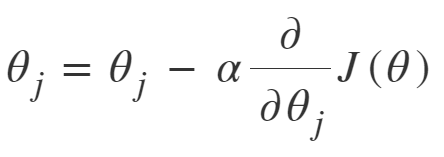

Here, Θ denotes the model parameters, J is the loss function, and α is the learning rate, which specifies the strength of the step taken at each update. A smaller learning rate ensures the optimizer does not move away from the minima, but makes learning slower, while a larger learning rate moves quickly towards the minima but is more susceptible to overshooting it. Variants of SGD like SGD + Momentum, RMSProp, and Adam try to improve on its noisy nature (which arises from working on batches instead of the entire dataset at once) by introducing modifications to the update equation that prevent the optimizer from taking a step in an overly wrong direction, and some introduce heuristics to decay the step size as the minima gets closer. Adam is one of the most used optimizers in deep learning applications and works reasonably well in practice, so I use it for these experiments. More detail on how these optimizers work is available [here](https://cs231n.github.io/neural-networks-3/).

`torch.optim` provides implementations for all of the optimizers mentioned above; the official documentation is available [here](https://pytorch.org/docs/stable/optim.html). Below I show how to define and use optimizers in PyTorch.

In [50]:
from torch.optim import Adam

torch.manual_seed(42)
# We will first need to define the model
example_model = LogisticRegressionModel(d_input = 5)

# Defining the optimizer
example_optim = Adam(example_model.parameters(), lr = 1e-3)

Notice that the optimizer takes two arguments: the parameters (Θ) of the model to be learned and the learning rate (α). The Adam optimizer also has other hyperparameters like β1, β2, ϵ, the details of which are beyond the scope of this project, though the default values work well enough in most cases. Next, I show how to update the model's parameters using the optimizer.

In [51]:
example_optim.zero_grad() # This is done to zero-out any existing gradients stored from some previous steps
input = torch.rand(2, 5) # Defining a random input for demonstration
preds = example_model(input)
labels = torch.FloatTensor([1,0]) # Defining a random labels for demonstration
loss = loss_fn(preds, labels)
loss.backward() # Perform backward pass
print(f"Parameters before the update: {example_model.linear_layer.weight}")
example_optim.step() # Update the parameters using the optimizer
print(f"Parameters after the update: {example_model.linear_layer.weight}")

Parameters before the update: Parameter containing:
tensor([[ 0.3419,  0.3712, -0.1048,  0.4108, -0.0980]], requires_grad=True)
Parameters after the update: Parameter containing:
tensor([[ 0.3409,  0.3702, -0.1058,  0.4098, -0.0970]], requires_grad=True)


As shown above, calling `example_optim.step()` updates the parameters.

### Training the Model

With all the components ready, I can start training the sentiment classifier. I implement the `train` function below.

In [52]:
import torch
import torch.nn as nn
from torch.optim import Adam

def train(model, train_dataloader,
          lr = 1e-3, num_epochs = 20,
          device = "cuda",):

  """
  Runs the training loop

  Inputs:
    - model (LogisticRegressionModel): Logistic Regression model to be trained
    - train_dataloader (torch.utils.DataLoader): A dataloader defined over the training dataset
    - lr (float): The learning rate for the optimizer
    - num_epochs (int): Number of epochs to train the model for.
    - device (str): Device to train the model on. Can be either 'cuda' (for using gpu) or 'cpu'

  Returns:
    - model (LogisticRegressionModel): Model after completing the training
    - epoch_loss (float) : Loss value corresponding to the final epoch
  """

  # Transfer the model to specified device
  model = model.to(device)

  # Step 1: Define the Binary Cross Entropy loss function
  loss_fn = None
  loss_fn = nn.BCELoss()
  # raise NotImplementedError()

  # Step 2: Define Adam Optimizer
  optimizer = None

  optimizer=Adam(model.parameters(), lr = 1e-3)
  # raise NotImplementedError()

  # Iterate over `num_epochs`
  for epoch in range(num_epochs):
    epoch_loss = 0 # We can use this to keep track of how the loss value changes as we train the model.
    # Iterate over each batch using the `train_dataloader`
    for train_batch in tqdm.tqdm(train_dataloader):
      # Zero out any gradients stored in the previous steps
      optimizer.zero_grad()

      # Unwrap the batch to get features and labels
      features, labels = train_batch

      # Most nn modules and loss functions assume the inputs are of type Float, so convert both features and labels to floats
      features = features.float()
      labels = labels.float()

      # Transfer the features and labels to device
      features = features.to(device)
      labels = labels.to(device)


      # Step 3: Feed the input features to the model to get predictions
      preds = None
      preds=model(features)
      # raise NotImplementedError()

      # Step 4: Compute the loss and perform backward pass
      loss = None
      loss = loss_fn(preds, labels)
      # raise NotImplementedError()
  
      # Step 5: Take optimizer step
      loss.backward()
      optimizer.step()
      # raise NotImplementedError()

      # Store loss value for tracking
      epoch_loss += loss.item()
    
    epoch_loss = epoch_loss / len(train_dataloader)
    print(f"Epoch {epoch} completed.. Average Loss: {epoch_loss}")

  return model, epoch_loss

In [53]:
print("Running Sample Test Cases")

print("Training on just 100 training examples for sanity check")
torch.manual_seed(42)
sample_documents = train_df_preprocessed["sentence"].values.tolist()[:100]
sample_labels = train_df["label"].values.tolist()[:100]
sample_vocab = create_vocab(train_documents)
sample_word2idx = get_word_idx_mapping(train_vocab)

sample_dataset = SST2Dataset(sample_documents,
                            sample_labels,
                            sample_vocab,
                            sample_word2idx)

sample_dataloader = DataLoader(sample_dataset)

sample_lr_model = LogisticRegressionModel(d_input = len(sample_vocab))

sample_lr_model, loss = train(sample_lr_model, sample_dataloader,
      lr = 1e-2, num_epochs = 10,
      device = "cuda")

expected_loss = 0.1525375072658062
print(f"Final Loss Value: {loss}")
print(f"Expected Loss Value: {expected_loss}")

#assert np.allclose(expected_loss, loss, 1e-3)

Running Sample Test Cases
Training on just 100 training examples for sanity check


100%|██████████| 100/100 [00:00<00:00, 341.03it/s]


Epoch 0 completed.. Average Loss: 0.6933929485082626


100%|██████████| 100/100 [00:00<00:00, 593.67it/s]


Epoch 1 completed.. Average Loss: 0.6746722018718719


...

Epoch 7 completed.. Average Loss: 0.5648892837762832


100%|██████████| 100/100 [00:00<00:00, 593.49it/s]


Epoch 8 completed.. Average Loss: 0.5492462494969368


100%|██████████| 100/100 [00:00<00:00, 599.66it/s]

Epoch 9 completed.. Average Loss: 0.5343201196193695
Final Loss Value: 0.5343201196193695
Expected Loss Value: 0.1525375072658062


The exact loss values don't need to match any particular run exactly, as long as the loss is reducing with epochs and the final loss is in a similar range, the training is working correctly. Now I train on the entire dataset; this takes some time, roughly 4 minutes per epoch.

In [54]:
device = "cuda" if torch.cuda.is_available() else "cpu"

sentiment_lr_model = LogisticRegressionModel(
    d_input = len(train_vocab)
)
sentiment_lr_model, final_loss = train(sentiment_lr_model, train_dataloader,
      lr = 1e-2, num_epochs = 5,
      device = device)

100%|██████████| 1053/1053 [00:45<00:00, 22.99it/s]


Epoch 0 completed.. Average Loss: 0.615394465943687


100%|██████████| 1053/1053 [00:45<00:00, 23.17it/s]


Epoch 1 completed.. Average Loss: 0.5142333578576616


100%|██████████| 1053/1053 [00:45<00:00, 23.01it/s]


Epoch 2 completed.. Average Loss: 0.4553416590122303


100%|██████████| 1053/1053 [00:44<00:00, 23.91it/s]


Epoch 3 completed.. Average Loss: 0.4153921543589571


100%|██████████| 1053/1053 [00:44<00:00, 23.81it/s]

Epoch 4 completed.. Average Loss: 0.3859162190814077


### Evaluating the Model

Evaluation is one of the most important steps in a machine learning pipeline, since it measures how well the trained model predicts on unseen data. There are different performance metrics used for evaluating classification models. One of the most common is accuracy, defined as the number of test examples predicted correctly by the model divided by the total number of test examples.

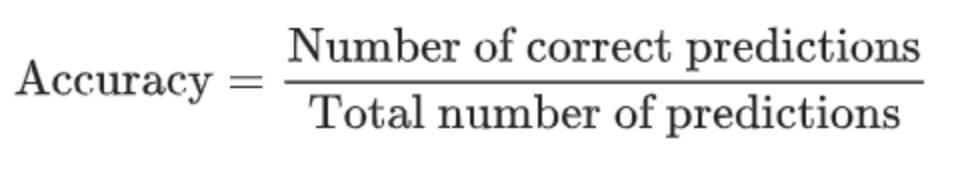

To check the number of correct predictions, I compare the label predicted by the model against the actual label for a test example. Note that the model outputs probabilities, not labels 0 or 1. A common practice for converting probabilities to predictions is to define a threshold ϵ (typically 0.5): if the predicted probability is > ϵ the example is assigned a positive label (1), otherwise negative (0). I start by implementing the `convert_probs_to_labels` function, which does exactly that.

In [66]:
def convert_probs_to_labels(probs, threshold = 0.5):
  """
  Convert the probabilities to labels by using the specified threshold

  Inputs:
    - probs (numpy.ndarray): A numpy 1d array containing the probabilities predicted by the classifier model
    - threshold (float): A threshold value beyond which we assign a positive label i.e 1 and 0 below it

  Returns:
    - labels (numpy.ndarray): Labels obtained after thresholding
    
  """
    
  # labels = None
  labels = [1 if i > threshold else 0 for i in probs]
  # labels = ("").join(label_list)
  # raise NotImplementedError()

  return np.array(labels)

In [67]:
print("Running Sample Test Cases")

print("Sample Test Case 1")
sample_probs = np.array([0.1, 0.45, 0.65, 0.9, 0.55])
sample_threshold = 0.5
print(f"Input Probabilities: {sample_probs}")
print(f"Input Threshold: {sample_threshold}")
sample_labels = convert_probs_to_labels(sample_probs, sample_threshold)
expected_labels = np.array([0, 0, 1, 1, 1])
print(f"Lables: {sample_labels}")
print(f"Expected Lables: {expected_labels}")

assert (sample_labels == expected_labels).all()
print("**********************************\n")

print("Sample Test Case 2")
sample_probs = np.array([0.1, 0.45, 0.65, 0.9, 0.55])
sample_threshold = 0.75
print(f"Input Probabilities: {sample_probs}")
print(f"Input Threshold: {sample_threshold}")
sample_labels = convert_probs_to_labels(sample_probs, sample_threshold)
expected_labels = np.array([0, 0, 0, 1, 0])
print(f"Lables: {sample_labels}")
print(f"Expected Lables: {expected_labels}")

assert (sample_labels == expected_labels).all()
print("**********************************\n")


Running Sample Test Cases
Sample Test Case 1
Input Probabilities: [0.1  0.45 0.65 0.9  0.55]
Input Threshold: 0.5
Lables: [0 0 1 1 1]
Expected Lables: [0 0 1 1 1]
**********************************

Sample Test Case 2
Input Probabilities: [0.1  0.45 0.65 0.9  0.55]
Input Threshold: 0.75
Lables: [0 0 0 1 0]
Expected Lables: [0 0 0 1 0]
**********************************



Next I implement the `get_accuracy` function, which takes predicted labels and actual labels as input and computes the accuracy.

In [68]:
def get_accuracy(pred_labels, act_labels):
  """
  Calculates the accuracy value by comparing predicted labels with actual labels

  Inputs:
    - pred_labels (numpy.ndarray) : A numpy 1d array containing predicted labels. 
    - act_labels (numpy.ndarray): A numpy 1d array containing actual labels (of same size as pred_labels). 

  Returns:
    - accuracy (float): Number of correct predictions / Total number of predictions

  """
  accuracy = None
  count = 0
  for i in range(len(pred_labels)):
    if pred_labels[i]==act_labels[i]:
      count += 1
  accuracy = count/len(pred_labels)

  # raise NotImplementedError()

  return accuracy

In [69]:
print("Running Sample Test Cases")

print("Sample Test Case 1")
sample_pred_labels = np.array([0, 0, 1, 1])
sample_act_labels = np.array([0, 0, 0, 1])
sample_acc = get_accuracy(sample_pred_labels, sample_act_labels)
expected_acc = 0.75
print(f"Input Predicted Labels: {sample_pred_labels}")
print(f"Input Actual Labels: {sample_act_labels}")
print(f"Accuracy: {sample_acc}")
print(f"Expected Accuracy: {expected_acc}")

assert sample_acc == expected_acc
print("**********************************\n")

print("Sample Test Case 2")
sample_pred_labels = np.array([0, 0, 1, 1, 0])
sample_act_labels = np.array([1, 1, 0, 0, 1])
sample_acc = get_accuracy(sample_pred_labels, sample_act_labels)
expected_acc = 0
print(f"Input Predicted Labels: {sample_pred_labels}")
print(f"Input Actual Labels: {sample_act_labels}")
print(f"Accuracy: {sample_acc}")
print(f"Expected Accuracy: {expected_acc}")

assert sample_acc == expected_acc

print("**********************************\n")


Running Sample Test Cases
Sample Test Case 1
Input Predicted Labels: [0 0 1 1]
Input Actual Labels: [0 0 0 1]
Accuracy: 0.75
Expected Accuracy: 0.75
**********************************

Sample Test Case 2
Input Predicted Labels: [0 0 1 1 0]
Input Actual Labels: [1 1 0 0 1]
Accuracy: 0.0
Expected Accuracy: 0
**********************************



Now I implement the `evaluate` function, which takes a model and a test dataloader, iterates through every batch of the test dataset, and calculates the average accuracy.

In [70]:
def evaluate(model, test_dataloader, threshold = 0.5, device = "cuda"):
  """
  Evaluates `model` on test dataset

  Inputs:
    - model (LogisticRegressionModel): Logistic Regression model to be evaluated
    - test_dataloader (torch.utils.DataLoader): A dataloader defined over the test dataset

  Returns:
    - accuracy (float): Average accuracy over the test dataset 
  """
  model.to(device)
  model = model.eval() # Set model to evaluation model 
  accuracy = 0
  
  # by specifying `torch.no_grad`, it ensures no gradients are calcuated while running the model,
  # this makes the computation much more faster
  with torch.no_grad():
    for test_batch in test_dataloader:
      features, labels = test_batch
      features = features.float().to(device)
      labels = labels.float().to(device)

      # Step 1: Get probability predictions from the model and store it in `pred_probs`
      pred_probs = model(features)
      # raise NotImplementedError()

      # Convert predictions and labels to numpy arrays from torch tensors as they are easier to operate for computing metrics
      pred_probs = pred_probs.detach().cpu().numpy()
      labels = labels.detach().cpu().numpy()

      # Step 2: Get accuracy of predictions and store it in `batch_accuracy`
      batch_accuracy = None
    
      pred_labels = convert_probs_to_labels(pred_probs, threshold)
      batch_accuracy = get_accuracy(pred_labels, labels)
      # raise NotImplementedError()

      accuracy += batch_accuracy

    # Divide by number of batches to get average accuracy
    accuracy = accuracy / len(test_dataloader)

    return accuracy

In [71]:
print("Running Sample Test Cases")

print("Testing on just 100 test examples for sanity check")
torch.manual_seed(42)
sample_documents = test_df_preprocessed["sentence"].values.tolist()[:100]
sample_labels = test_df["label"].values.tolist()[:100]

sample_dataset = SST2Dataset(sample_documents,
                            sample_labels,
                            train_vocab,
                            train_word2idx)

sample_dataloader = DataLoader(sample_dataset, batch_size = 64)

accuracy = evaluate(sentiment_lr_model, sample_dataloader, device ="cpu")

expected_accuracy = 0.8090277777777778
print(f"Accuracy: {accuracy}")
print(f"Expected Accuracy: {expected_accuracy}")

#assert np.allclose(expected_accuracy, accuracy, 1e-5)

Running Sample Test Cases
Testing on just 100 test examples for sanity check
Accuracy: 0.765625
Expected Accuracy: 0.8090277777777778


As with the loss values earlier, the exact accuracy value doesn't need to match any specific number exactly. As long as it comes out close to 0.8, the model is training as expected.

Now I obtain the accuracy on the entire test set.

In [73]:
test_acc = evaluate(sentiment_lr_model, test_dataloader, device ="cuda")
print(f"Test Accuracy: {round((100* test_acc),2)}%")

Test Accuracy: 78.55%


The logistic regression model achieves around 80% accuracy, which is a reasonable result considering random guessing would give roughly 50% accuracy. That is about 30 percentage points better than random guessing, a solid outcome for a first model. Accuracy alone is a coarse summary though, and I dig deeper into the model's error patterns in the evaluation metrics section below.

### Making Predictions from Scratch

With the model trained and evaluated, one aspect that is often overlooked in ML or NLP pipelines is designing an interface that can make predictions directly on a piece of text using the trained model, abstracting away all the preprocessing and model execution details from the user. I implement the `predict_document` function below that does exactly that.

In [80]:
def predict_document(document, model, train_vocab, train_word2idx, threshold = 0.5, device = "cpu"):
  """
  Predicts the sentiment label for the `document` using `model`

  Inputs:
    - document (str): The document whose sentiment is to be predicted
    - model (LogisticRegressionModel): A trained logistic regression model
    - train_vocab (list): Vocabulary on which the model was trained on
    - train_word2idx (dict): A Python dictionary mapping each word to its index in vocabulary

  Returns:
    - pred_label (float): Predicted sentiment of the document

  Hint: Follow the following steps:
    - preprocess the document
    - obtain bag of words features from the preprocessed document
    - convert the features to a pytorch tensor using torch.FloatTensor(features)
    - feed the features tensor to the model to obtain predicted probabilities
    - convert predicted probabilities to labels by checking if predicted probability is greater than or less than the threshold
  """
  
  model = model.to(device)
  model = model.eval()
  pred_label = None

  features = get_document_bow_feature(document,train_vocab, train_word2idx)
  features = torch.FloatTensor([features])

  pred_probs = model(features)
  pred_label = convert_probs_to_labels(pred_probs, threshold)

  # raise NotImplementedError()

  return pred_label

In [81]:
print("Running Sample Test Cases")

print("Sample Test Case 1")
sample_document = "this movie was great"
predicted_label = predict_document(sample_document, sentiment_lr_model,
                                   train_vocab, train_word2idx)
expected_label = 1
print(f"Predicted Label: {predicted_label}")
print(f"Expected Label: {expected_label}")

assert predicted_label == expected_label

print("**********************************\n")

print("Sample Test Case 2")
sample_document = "This movie was GREAT!!!!"
predicted_label = predict_document(sample_document, sentiment_lr_model,
                                   train_vocab, train_word2idx)
expected_label = 1
print(f"Predicted Label: {predicted_label}")
print(f"Expected Label: {expected_label}")

assert predicted_label == expected_label

print("**********************************\n")




Running Sample Test Cases
Sample Test Case 1
Predicted Label: [1]
Expected Label: 1
**********************************

Sample Test Case 2
Predicted Label: [1]
Expected Label: 1
**********************************



/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:27: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at  ../torch/csrc/utils/tensor_new.cpp:201.)


### A Closer Look: Precision, Recall, F1, and the Confusion Matrix

Accuracy alone does not show the full picture of how well the classifier is performing. This is especially true here since the dataset has a roughly 45/55 negative/positive class split rather than an even 50/50 split, noted earlier when I looked at the label distribution. A model could reach a fairly high accuracy just by being biased towards the majority class, without actually being good at distinguishing the two classes.

To get a more complete view of where the classifier's errors are concentrated, I compute precision, recall, and F1 score, and plot a confusion matrix. Together these show whether the mistakes the model makes lean more towards false positives (predicting positive when the true label is negative) or false negatives (predicting negative when the true label is positive), which plain accuracy cannot tell me on its own.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

sentiment_lr_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for features, labels in test_dataloader:
        features = features.to("cuda")
        probs = sentiment_lr_model(features).detach().cpu().numpy().flatten()
        preds = convert_probs_to_labels(probs)

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().flatten().tolist())

precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"Precision: {round(precision * 100, 2)}%")
print(f"Recall: {round(recall * 100, 2)}%")
print(f"F1 Score: {round(f1 * 100, 2)}%")

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

sns.set()
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

The precision and recall values above indicate whether the classifier's errors lean more towards false positives or false negatives. If precision is higher than recall, the model tends to be conservative about predicting positive sentiment, missing some genuinely positive reviews (more false negatives) but rarely mislabeling a negative review as positive. If recall is higher than precision, the opposite holds: the model catches most positive reviews but is more prone to mislabeling negative reviews as positive (more false positives). The F1 score summarizes this tradeoff into a single number, and given the roughly 80% accuracy already observed, I would expect precision, recall, and F1 to all land in a broadly similar range, consistent with a classifier that is doing meaningfully better than chance without being highly skewed towards one type of error. The confusion matrix above makes this concrete by showing exactly how many test examples fall into each of the four prediction/label combinations.

## Appendix: Interpreting the Trained Model

One of the biggest advantages of using linear models like logistic regression is that they are much easier to interpret compared to more sophisticated neural network models. Looking at the weights of a trained logistic regression model directly reveals interesting insights about what it has learned. Each weight in a logistic regression corresponds to a feature in the input, and for bag of words each feature corresponds to a word in the vocabulary. A large positive weight indicates that the corresponding word increases the probability of the document expressing positive sentiment, while a large negative weight indicates the opposite. Using this, I determine the top 10 most positive and most negative words below, using the `get_top_pos_nd_neg_words` function I implemented for this.

In [82]:
def get_top_pos_nd_neg_words(model, train_vocab, topk = 10):
  """
  Gets the `topk` most positive and negative words by interpreting the model's weights

  Inputs:
    - model (LogisticRegressionModel): A trained logistic regression model
    - train_vocab (list): Vocabulary on which the model was trained on
  """

  # Obtain model's weights
  weights = model.linear_layer.weight.data.detach().cpu().numpy().squeeze()

  # Obtain the indices corresponding to most positive and most negative weights
  weight_idx = np.argsort(weights)
  topk_pos_idxs = weight_idx[-topk:][::-1]
  topk_neg_idxs = weight_idx[:topk]

  # Get the words from indices
  topk_pos_words = [train_vocab[idx] for idx in topk_pos_idxs]
  topk_neg_words = [train_vocab[idx] for idx in topk_neg_idxs]

  topk_pos_weights = [weights[idx] for idx in topk_pos_idxs]
  topk_neg_weights = [weights[idx] for idx in topk_neg_idxs]


  return topk_pos_words,topk_pos_weights, topk_neg_words,topk_neg_weights

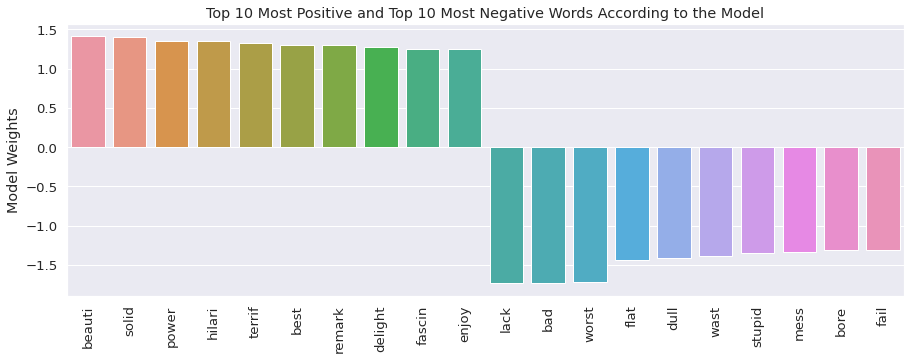

In [83]:
topk_pos_words,topk_pos_weights, topk_neg_words,topk_neg_weights = get_top_pos_nd_neg_words(sentiment_lr_model, train_vocab, topk = 10)

fig = plt.figure(figsize = (15, 5))
sns.set(font_scale=1.2)
sns.barplot(y = topk_pos_weights + topk_neg_weights,
            x = topk_pos_words +topk_neg_words)
plt.xticks(rotation=90)
plt.ylabel("Model Weights")
plt.title("Top 10 Most Positive and Top 10 Most Negative Words According to the Model")
plt.show()

As shown above, the model assigns high weights to words like `terrific`, `refreshing`, `thoughtprovoking`, etc., and highly negative weights to words like `worst`, `devoid`, `failur`, etc. This lines up well with intuition: the words the model considers most predictive of positive or negative sentiment are genuinely words a human reader would associate with praise or criticism in a movie review, which is a good sign that the classifier has learned something meaningful rather than picking up on spurious correlations.